In [39]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using LaTeXStrings
using FFTW, Interpolations
using Tullio
using JLD2

## 1) Model and parameter definitions
We evolve a driven 1D tight-binding electron system coupled to a bosonic bath on the Keldysh contour. The electronic band is
$$
\varepsilon_k = u - 2\gamma\cos k,
$$
with discrete lattice momenta $k\in[-\pi,\pi)$ and periodic wrapping. The tensor `kmq_idx` precomputes the map $k-q\mapsto$ valid grid index, so each self-energy update is an explicit momentum-transfer convolution instead of repeated modular arithmetic.

Key scales in this section:
- $\gamma$: hopping (energy/time unit in most plots),
- $u$: onsite shift of the band center,
- $T$: temperature entering Fermi/Bose factors,
- $(L,\Delta t,t_\mathrm{max})$: momentum and time resolution.

`w_q`, $\omega_q$, and $g_q^2$ are normalized/constructed once here so later kernels keep a transparent prefactor structure.


In [48]:
"""
    make_momentum_weights(profile; ks, s_q, λ_q)

Build normalized bath-momentum weights `w_q` used in the q-sum kernel.
For `:power_exp`, the profile is |q|^s_q exp(-|q|/λ_q).
"""
function make_momentum_weights(profile::Symbol; ks, s_q::Float64, λ_q::Float64)
    if profile == :uniform
        # Flat sampling of transferred momenta q.
        wq_raw = ones(Float64, length(ks))
    elseif profile == :power_exp
        # Phenomenological momentum preference entering Ξ_q through w_q.
        wq_raw = abs.(ks) .^ s_q .* exp.(-abs.(ks) ./ λ_q)
    else
        throw(ArgumentError("Unknown momentum weight profile: $profile"))
    end

    # Normalize so that Σ_q w_q = 1 (keeps overall coupling scale explicit elsewhere).
    wq_sum = sum(wq_raw)
    wq_sum > 0 || throw(ArgumentError("Momentum weights must sum to a positive value before normalization"))
    return wq_raw ./ wq_sum
end

"""Return ω_q for one bath mode q under the selected dispersion model."""
function ωbath_value(q::Real; dispersion_type::Symbol, ωb0::Float64, v_b::Float64)
    if dispersion_type == :linear
        return ωb0 + v_b * abs(q)
    elseif dispersion_type == :sin_lattice
        return ωb0 + 2v_b * abs(sin(q / 2))
    else
        throw(ArgumentError("Unknown dispersion_type: $dispersion_type"))
    end
end

"""Vectorized constructor of bath dispersion ω_q on the chosen momentum grid."""
function make_bath_dispersion(dispersion_type::Symbol; qs, ωb0::Float64, v_b::Float64)
    [ωbath_value(q; dispersion_type, ωb0, v_b) for q in qs]
end

"""Return momentum-independent g_q^2 used by the explicit-dispersion bath option."""
function make_bath_coupling2(; qs, g_b::Float64)
    fill(g_b^2, length(qs))
end

Base.@kwdef struct ModelElectronBath{Hk}
    # Lattice and electron parameters (1D tight-binding convention).
    L::Int = 100
    T::Float64 = 0.8 ### Cold
    u::Float64 = 0.0
    γ::Float64 = 1.0

    # Spectral-density bath parameters J(ω) ~ α |ω|^s exp(-|ω|/ωc).
    α::Float64 = 0.2
    s::Float64 = 1.0
    ωc::Float64 = 3.0

    # Drive envelope and carrier: A(t) = A exp[-(t-t0)^2/(2σ^2)] sin(ω0 t).
    t0::Float64 = 20.0
    ω0::Float64 = 2.2
    σ::Float64 = 2.0
    A::Float64 = 0.0

    # Smooth switch-on window stepp(t).
    ti::Float64 = 3.0
    to::Float64 = 20.0

    # Bath implementation choice: continuum spectral density vs explicit q-dispersion.
    bath_type::Symbol = :spectral_density
    dispersion_type::Symbol = :linear
    ωb0::Float64 = 0.2
    v_b::Float64 = 1.0
    g_b::Float64 = 0.1

    # Discrete Brillouin-zone grid k_j = -π + jΔk, j=0..L-1.
    Δk = 2*pi/L
    ks = collect(range(-pi, stop=pi-Δk, length=L))

    # Optional momentum weighting for homogeneous kernels in q-space.
    wq_profile::Symbol = :uniform
    s_q::Float64 = 0.0
    λ_q::Float64 = 1.0
    wq::Vector{Float64} = make_momentum_weights(wq_profile; ks, s_q, λ_q)

    # Explicit bath arrays used when bath_type == :dispersion.
    bath_qs::Vector{Float64} = copy(ks)
    ωq::Vector{Float64} = make_bath_dispersion(dispersion_type; qs=bath_qs, ωb0, v_b)
    g2q::Vector{Float64} = make_bath_coupling2(; qs=bath_qs, g_b)
    nBq::Vector{Float64} = bose.(ωq; model=(; T))

    # Momentum-conservation map k-q (periodic indexing on the discrete grid).
    kmq_idx::Matrix{Int} = [mod1(k - q, L) for k in 1:L, q in 1:L]

    # Time-dependent single-particle dispersion ε_{k-A(t)}.
    hk::Hk = t -> ϵ_k.(ks .- pulse_Gaussian_sin(t; t0, ω0, σ, A); u, γ)
end


## 2) Drive definition and equilibrium distributions
The external field is implemented through a Peierls substitution
$$
k \rightarrow k - A(t),
$$
so the instantaneous single-particle Hamiltonian is $h_k(t)=\varepsilon_{k-A(t)}$.

For the Gaussian-sine pulse used here,
$$
A(t)=A_0\,\exp\!\left[-\frac{(t-t_0)^2}{2\sigma^2}\right]\sin(\omega_0 t),
$$
which injects energy mainly near $t\approx t_0$ and becomes negligible for $|t-t_0|\gg \sigma$.

Useful consistency limits:
- **No drive** ($A_0=0$): time-translation invariance is recovered (up to finite-grid effects).
- **Weak drive**: changes in $G^{</>}$ are perturbative around equilibrium occupations.
- **Long times after pulse**: explicit drive term vanishes, dynamics is controlled by memory and bath scattering.


In [58]:
Base.@kwdef struct DataElectronBath{T}
    # Two-time electronic Green's functions G^< and G^> (k-resolved).
    GL::T
    GG::T
    # q-resolved bath kernels Ξ^</>_q(t,t').
    ΞL_q::T
    ΞG_q::T
    # Fock self-energies Σ^</>_F(k,t,t').
    ΣL_F::T
    ΣG_F::T
end

"""Tight-binding band ε_k = u - 2γ cos(k)."""
function ϵ_k(k; u::Float64, γ::Float64)
    u .- 2 * γ * cos.(k)
end

"""Fermi distribution at the model temperature."""
function fermi(ϵ; model)
    (; T) = model
    β = 1 / T
    return 1 / (exp(β * ϵ) + 1)
end

"""Bose distribution at the model temperature (regularized at |ϵ|≈0)."""
function bose(ϵ; model)
    (; T) = model
    β = 1 / T
    if abs(ϵ) < 1e-5
        return 0.0
    end
    return 1 / (exp(β * ϵ) - 1)
end

# Vector potential A(t) entering the Peierls substitution k -> k - A(t).
function pulse_Gaussian_sin(t; t0::Float64, ω0::Float64, σ::Float64, A::Float64)
    A * exp(-0.5 * (t - t0)^2 / σ^2) * sin(t * ω0) + pi/4
end

# Free lesser Green's function used for initial intuition/checks.
function g0l(t; model::ModelElectronBath)
    ϵ = ϵ_k(model.ks .- pulse_Gaussian_sin(t; model.t0, model.ω0, model.σ, model.A); u=model.u, γ=model.γ)
    return 1im * fermi.(ϵ; model) .* exp.(-1im * ϵ * t)
end

# Free greater Green's function companion to g0l.
function g0g(t; model::ModelElectronBath)
    ϵ = ϵ_k(model.ks .- pulse_Gaussian_sin(t; model.t0, model.ω0, model.σ, model.A); u=model.u, γ=model.γ)
    return 1im * (fermi.(ϵ; model) .- 1) .* exp.(-1im * ϵ * t)
end

"""Odd spectral density J(ω) used in the continuum-bath construction."""
function J(ω; model::ModelElectronBath)
    (; α, s, ωc) = model
    sign = ω ≥ 0 ? 1 : -1
    return sign * α * ωc^(1 - s) * (abs(ω))^s * exp(-sign * ω / ωc)
end

# Ξ^<(t) from frequency integration of J(ω) n_B(ω) e^{-iωt}.
function Ξl(t; model::ModelElectronBath)
    dω = 0.01
    ωmax = 200.0
    ωs = vcat(-ωmax:dω:-dω, dω:dω:ωmax)
    return -1im / (2pi) * sum(J.(ωs; model) .* bose.(ωs; model) .* exp.(-1im * ωs * t)) * dω
end

# Ξ^>(t) from frequency integration of J(ω) [n_B(ω)+1] e^{-iωt}.
function Ξg(t; model::ModelElectronBath)
    dω = 0.01
    ωmax = 200.0
    ωs = vcat(-ωmax:dω:-dω, dω:dω:ωmax)
    return -1im / (2pi) * sum(J.(ωs; model) .* (bose.(ωs; model) .+ 1) .* exp.(-1im * ωs * t)) * dω
end

"""Smooth switch-on factor multiplying interaction kernels in time."""
function stepp(t; model::ModelElectronBath)
    (; ti, to) = model
    return 1 / (1 + exp(-(t - to) / ti))
end


stepp (generic function with 1 method)

## 3) Kernel construction and self-energy update
The bath enters through bosonic kernels $\Xi_q^{</>}(t,t')$ and a Fock/Born convolution
$$
\Sigma_k^{</>}(t,t') = i\sum_q \Xi_q^{</>}(t,t')\,G_{k-q}^{</>}(t,t').
$$
The code supports two levels:
1. **Homogeneous kernel**: same two-time shape for all $q$, multiplied by weights $w_q$.
2. **Dispersion-resolved kernel**: explicit $\omega_q$, $g_q^2$, and $n_B(\omega_q)$ per transferred momentum.

The normalization $\sum_q w_q=1$ isolates overall coupling strength in explicit prefactors (instead of hiding it in the discrete sum), which makes parameter scans easier to interpret.


In [59]:
function homogeneous_momentum_sum(Gtt)
    sumG = similar(Gtt)
    sumG .= sum(Gtt)
    return sumG
end

"""Populate Ξ_q(t,t') = w_q Ξ_ref for homogeneous kernels."""
function weighted_kernel_q_from_homogeneous!(Ξq, Ξref, wq, t, t′)
    Ξq_tt = Ξq[t, t′]
    @inbounds for q in eachindex(wq)
        Ξq_tt[q] = wq[q] * Ξref
    end
end

"""Construct explicit-dispersion bath kernel Ξ_q^</>(τ)."""
function fill_dispersion_kernel_q!(Ξq_tt, τ, ωq, g2q, nBq; greater::Bool)
    @inbounds for q in eachindex(Ξq_tt)
        nq = nBq[q]
        pref = greater ? (nq + 1) : nq
        pref_tr = greater ? nq : (nq + 1)
        Ξq_tt[q] = -1im * g2q[q] * (pref * exp(-1im * ωq[q] * τ) + pref_tr * exp(1im * ωq[q] * τ))
    end
    return Ξq_tt
end

"""
Convolution Σ_k = i Σ_q Ξ_q G_{k-q} at fixed (t,t').
`kmq_idx` encodes periodic k-q indexing on the discrete grid.
"""
function apply_momentum_convolution!(Σtt, Ξq_tt, Gtt, kmq_idx)
    fill!(Σtt, 0)
    L = length(Σtt)

    @inbounds for k in 1:L
        acc = zero(eltype(Σtt))
        for q in eachindex(Ξq_tt)
            acc += Ξq_tt[q] * Gtt[kmq_idx[k, q]]
        end
        Σtt[k] = 1im * acc
    end

    return Σtt
end

"""Update Ξ^</> and Σ_F^</> at one two-time grid point (t,t')."""
function SelfEnergyUpdate!(model::ModelElectronBath, data::DataElectronBath
        , times::Vector{Float64}, _, _, t::Int, t′::Int)
    (; GL, GG, ΞL_q, ΞG_q, ΣL_F, ΣG_F) = data
    (; bath_type, wq, kmq_idx, ωq, g2q, nBq) = model

    # Ensure auxiliary arrays grow with solver-time expansion.
    if (n = size(GL, 3)) > size(ΣL_F, 3)
        resize!(ΞL_q, n)
        resize!(ΞG_q, n)
        resize!(ΣL_F, n)
        resize!(ΣG_F, n)
    end

    τ = times[t] - times[t′]
    # Adiabatic interaction switch-on on both contour branches.
    s = stepp(times[t]; model) * stepp(times[t′]; model)

    if bath_type == :spectral_density
        ΞL = Ξl(τ; model) * s
        ΞG = Ξg(τ; model) * s
        weighted_kernel_q_from_homogeneous!(ΞL_q, ΞL, wq, t, t′)
        weighted_kernel_q_from_homogeneous!(ΞG_q, ΞG, wq, t, t′)
    elseif bath_type == :dispersion
        fill_dispersion_kernel_q!(ΞL_q[t,t′], τ, ωq, g2q, nBq; greater=false)
        fill_dispersion_kernel_q!(ΞG_q[t,t′], τ, ωq, g2q, nBq; greater=true)
        ΞL_q[t,t′] .*= s
        ΞG_q[t,t′] .*= s
    else
        throw(ArgumentError("Unknown bath_type: $(bath_type). Use :spectral_density or :dispersion."))
    end

    # Born/Fock self-energy from bath kernel and current electronic G^</>.
    apply_momentum_convolution!(ΣL_F[t,t′], ΞL_q[t,t′], GL[t,t′], kmq_idx)
    apply_momentum_convolution!(ΣG_F[t,t′], ΞG_q[t,t′], GG[t,t′], kmq_idx)
    return nothing
end


SelfEnergyUpdate! (generic function with 1 method)

### Momentum-transfer structure and homogeneous limit
`update_\Sigma_F!` performs the discrete convolution over transferred momentum $q$ using `kmq_idx`:
$$
(k,q)\mapsto k-q \; (\mathrm{mod}\ 2\pi).
$$
Two useful limits are implemented explicitly:
- `homogeneous=true`: replace momentum-resolved $G_{k-q}$ by a momentum sum, so all $k$ feel the same bath average.
- `homogeneous=false`: retain full $k$-dependence and momentum-selective scattering pathways.

Comparing these two modes isolates which features are caused by momentum structure versus purely temporal memory.


## 4) KBE memory integrals
The helper integrators implement discrete Volterra convolutions appearing in the Kadanoff--Baym equations,
$$
(\Sigma\circ G)(t,t') = \int_0^t d\bar t\,\Sigma(t,\bar t)G(\bar t,t'),
$$
and the companion branch with upper limit $t'$. Numerical quadrature weights (`h1`,`h2`) are kept explicit, so causality is enforced by construction through integration bounds.

A practical check: in the noninteracting limit ($\Sigma\to 0$), these memory terms vanish and the solver reduces to unitary band evolution with the driven $h_k(t)$.


In [60]:
"""∫_0^{tmax} dt1 [A(t,t1)-B(t,t1)] C(t1,t') with quadrature weights hs."""
function integrate1(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    ret = zero(A[:, t1, t1])

    @inbounds for k in 1:tmax
        @views ret .+= (A[:, t1, k] .- B[:, t1, k]) .* C[:, k, t2] * hs[k]
    end

    return ret
end

"""∫_0^{tmax} dt1 A(t,t1) [B(t1,t')-C(t1,t')] with weights hs."""
function integrate2(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t2)
    ret = zero(A[:, t1, t1])

    @inbounds for k in 1:tmax
        @views ret .+= A[:, t1, k] .* (B[:, k, t2] .- C[:, k, t2]) * hs[k]
    end

    return ret
end

"""Equal-time helper integral entering optional retarded terms."""
function integrate3(hs::Vector, t1, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    ret = zero(A[:, t1, t1])

    @inbounds for k in 1:tmax
        @views ret .+= (A[:, t1, k] .- B[:, t1, k]) .* C[:, k, k] * hs[k]
    end

    return ret
end


integrate3 (generic function with 1 method)

## 5) KBE propagation equations
`fv!` evaluates the two-time equation of motion for each momentum component,
$$
i\partial_t G^{</>}_k(t,t') = h_k(t)G^{</>}_k(t,t') + (\Sigma^R\circ G^{</>} + \Sigma^{</>}\circ G^A)_k(t,t'),
$$
implemented in a component form using $\Sigma^{</>}$ combinations.

`fd!` imposes the equal-time symmetry/anti-Hermiticity constraint needed for stable propagation on the diagonal $t=t'$. This is essential because diagonal values set occupations and feed back into subsequent memory updates.


In [61]:
"""
Right-hand side of the two-time KBE for (G^<, G^>) at fixed (t,t').
Outputs are written in-place to `out` following kbsolve!'s interface.
"""
function fv!(model::ModelElectronBath, data::DataElectronBath, out::AbstractVector{<:AbstractArray{ComplexF64,1}}
        , times::Vector{Float64}, h1::Vector, h2::Vector, t::Int, t′::Int)
    (; GL, GG, ΣL_F, ΣG_F) = data
    (; hk) = model

    # Memory integrals on the two Keldysh branches with solver quadrature weights.
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)

    # KBE equation of motion: i∂_t G = h(t)G + Σ ⊗ G terms.
    out[1] = -1im * ( hk(times[t] ).* GL[t, t′]  + ∫dt1(ΣG_F, ΣL_F, GL) + ∫dt2(ΣL_F, GL, GG))
    out[2] = -1im * ( hk(times[t] ).* GG[t, t′]  + ∫dt1(ΣG_F, ΣL_F, GG) + ∫dt2(ΣG_F, GL, GG))
    return nothing 
end

"""Equal-time derivative constraint enforcing skew-Hermitian structure."""
function fd!(model::ModelElectronBath, data::DataElectronBath
        , out::AbstractVector{<:AbstractArray{ComplexF64,1}}
        , times::Vector{Float64}, h1::Vector, h2::Vector, t::Int, t′::Int)
    fv!(model, data, out, times, h1, h2, t, t)
    out .-= conj(out)
    return nothing
end


fd! (generic function with 1 method)

In [53]:
#model = ModelElectronBath()
#fermi.(ϵ_k.(model.ks;  model.u , model.γ); model)

In [54]:
#model.ks

## 6) Full simulation driver
`main` orchestrates a self-consistent loop:
1. initialize Green's functions from equilibrium-like initial conditions,
2. build initial bath kernels and $\Sigma_F^{</>}$,
3. propagate with `kbsolve!` while updating self-energies at each new time slice,
4. save $(G^<,G^>,t)$ for analysis.

This separation between model setup, kernel update, and propagation makes it straightforward to compare homogeneous vs momentum-dependent baths without changing solver logic.


In [62]:
"""
Main simulation driver:
1) initialize model and two-time objects,
2) build initial Σ_F from Ξ and G,
3) propagate KBEs with self-energy callback,
4) save GL, GG, and time grid.
"""
function main(; kwargs...)
    #### Read kwargs 
    name = "test"
    println(kwargs...)
    #### Setting the initial parameters
    model = ModelElectronBath(;kwargs...)
    

    L  = model.L
    @assert model.bath_type in (:spectral_density, :dispersion) "bath_type must be :spectral_density or :dispersion"
    @assert model.dispersion_type in (:linear, :sin_lattice) "dispersion_type must be :linear or :sin_lattice"
    @assert length(model.wq) == L "wq must have length L"
    @assert isapprox(sum(model.wq), 1.0; atol=1e-12) "wq must satisfy sum(wq) = 1"
    @assert length(model.ωq) == L "ωq must have length L"
    @assert length(model.g2q) == L "g2q must have length L"
    u  = model.u
    γ  = model.γ
    ks = model.ks 
    (; T, α, s, ωc, t0, ω0, σ, A, ti, to) = model

    #### Initial two-time objects ####
    GL = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)
    GG = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)
    ΞL_q = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)
    ΞG_q = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)
    ΣL_F = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)
    ΣG_F = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian)

    #### Equal-time initial conditions ####
    # Convention: n_k(t) = Im[G^<(k,t,t)], so G^>(t,t)=G^<(t,t)-i.
    GL[1, 1] = 1im * fermi.(ϵ_k.(ks;  u=u , γ=γ ); model)
    GG[1, 1] = GL[1, 1] .- 1im

    # Initialize bath kernels and corresponding Fock self-energies at (t=0,t'=0).
    if model.bath_type == :spectral_density
        weighted_kernel_q_from_homogeneous!(ΞL_q, Ξl(0.0; model), model.wq, 1, 1)
        weighted_kernel_q_from_homogeneous!(ΞG_q, Ξg(0.0; model), model.wq, 1, 1)
    else
        fill_dispersion_kernel_q!(ΞL_q[1,1], 0.0, model.ωq, model.g2q, model.nBq; greater=false)
        fill_dispersion_kernel_q!(ΞG_q[1,1], 0.0, model.ωq, model.g2q, model.nBq; greater=true)
    end
    apply_momentum_convolution!(ΣL_F[1,1], ΞL_q[1,1], GL[1,1], model.kmq_idx)
    apply_momentum_convolution!(ΣG_F[1,1], ΞG_q[1,1], GG[1,1], model.kmq_idx)
    
    #### Bundle dynamic state passed to solver callbacks ####
    data = DataElectronBath(GL=GL, GG=GG, ΞL_q=ΞL_q, ΞG_q=ΞG_q, ΣL_F=ΣL_F, ΣG_F=ΣG_F)

    #### Time propagation controls ####
    tmax = 40#50
    atol = 1e-5#6
    rtol = 1e-4#5

    sol = @time kbsolve!(
        (x...) -> fv!(model, data, x...),
        (x...) -> fd!(model, data, x...),
        [data.GL, data.GG],
        (0.0, tmax);
        callback = (x...) -> SelfEnergyUpdate!(model, data, x...),
        atol = atol,
        rtol = rtol,
        stop = x -> (println("t: $(x[end])"); flush(stdout); false)
    )
   
    file   = "Data"
    name_p = "test_gi"#"open_chain"
    
    @save "$(file)/GL_$(name_p).jld2" GL
    @save "$(file)/GG_$(name_p).jld2" GG
    @save "$(file)/ts_$(name_p).jld2" sol

    println("Saved all results.")
end


main (generic function with 1 method)

In [63]:
main()


t: 0.0
t: 1.0e-6
t: 5.999999999999999e-6
t: 3.0999999999999995e-5
t: 0.00015599999999999997
t: 0.0007809999999999998
t: 0.0013434999999999996
t: 0.0018497499999999994
t: 0.004380999999999998
t: 0.01703724999999999
t: 0.028427874999999984
t: 0.08538099999999996
t: 0.13663881249999993
t: 0.2558168310567094
t: 0.36307704775774785
t: 0.475060680856081
t: 0.5855404414953953
t: 0.7056010170813269
t: 0.8359832163661655
t: 0.9688929195645234
t: 1.1017285526054514
t: 1.2340268207189053
t: 1.3672320019440523
t: 1.5021615130774997
t: 1.6384315924926336
t: 1.7753239764839783
t: 1.9125074122741375
t: 2.0501116883617505
t: 2.1883528846136655
t: 2.3272731013098715
t: 2.4667665487229526
t: 2.606729006829696
t: 2.7471363632498216
t: 2.888014218341433
t: 3.029378466970344
t: 3.171214235309867
t: 3.3134936466844045
t: 3.4561975325522987
t: 3.5993193442833866
t: 3.7428561859810423
t: 3.886801269216323
t: 4.031143953450566
t: 4.175873668675141
t: 4.320982242591466
t: 4.4664632375558515
t: 4.61231031260082

## Figures

In [16]:
using PyPlot
using FFTW, Interpolations
using JLD2
using Tullio
rc("text", usetex=true)
rc("font", family="serif")
rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)

In [17]:
#151.781253/60

## 7) Observable extraction and post-processing
Post-processing separates two complementary objects:
- **Equal-time observables** (e.g. $n_k(t)=-iG_k^<(t,t)$, and momentum average $N(t)=L^{-1}\sum_k n_k(t)$), sensitive to occupations.
- **Two-time/frequency observables** from Wigner transforms, sensitive to spectral redistribution and nonequilibrium populations.

Interpreting both is important: equal-time quantities can look nearly relaxed even when two-time structure still carries memory.


In [18]:
filed = "Data"
pulsed = "Gaussian_sin"
name = "test"
L = 100
# T = 0.1
# α = 1.0
# u = 0.0
# γ = 1.0
# s = 1.0
# ωc = 1.0
# t0 = 50.0
# ω0 = pi
# σ = 2.0
# A = 1.0
# ti = 3
# # to = 20
# tmax = 30.0#100
# atol = 1.0e-5
# rtol = 1.0e-4

# L::Int      = 40
# T::Float64  = 1.0
# u::Float64  = 0.0
# γ::Float64  = 1.0
# α::Float64  = 0.0
# s::Float64  = 1.0
# ωc::Float64 = 1.0#10.0
# t0::Float64 = 50.0
# ω0::Float64 = Float64(pi)
# σ::Float64  = 2.0
# A::Float64  = 0.0
# ti::Float64 = 3.0
# to::Float64 = 20.0
# GG_Jantisymmetric_Gaussian_sin_T0.1_α1.0_s1.0_ωc1.0_t050.0_ω0π_σ2.0_A1.0_ti3_to20_tmax200_atol1.0e-6_rtol1.0e-5

#name_p = "N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)_tmax$(tmax)_atol$(atol)_rtol$(rtol)"
#name_p = "closed_chain"#"N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)"
# dataL = load("$(filed)/GL_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
# dataG = load("$(filed)/GG_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
# datats = load("$(filed)/ts_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
name_p = "driven_chain"

dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");

GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];

Δk = 2*pi/L
ks = collect(range(-pi, stop=pi-Δk, length=L))

size(GL_data)

(100, 487, 487)

In [19]:
ts = ts_data.t;
size(ts)


(487,)

### Equal-time normalization checks
For fermions in this convention, $n_k(t)=-iG_k^<(t,t)$ should stay real (up to numerics). Practical diagnostics:
$$
N(t)=\frac{1}{L}\sum_k n_k(t),
$$
which should remain approximately conserved for number-conserving approximations. Slow drift typically indicates timestep/quadrature error or insufficient self-consistency tolerance.


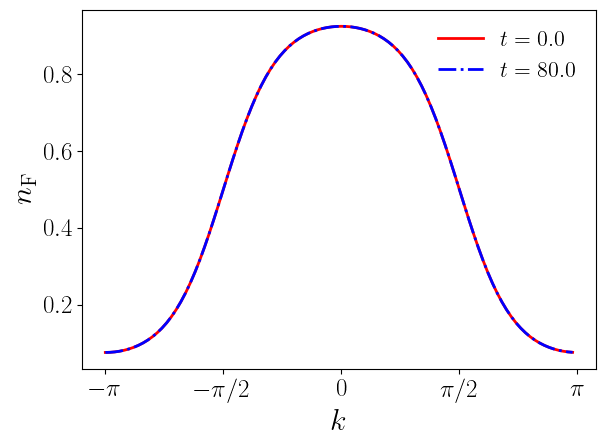

In [20]:
t1 = 1
t2 = length(ts)
sol_t1 = ts[t1]
sol_t2 = ts[t2]
nf_t1  = imag.(GL_data[t1,t1])
nf_t2 = imag.(GL_data[t2,t2])

plot(ks, nf_t1; color="red", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t2; color="blue", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="-.")
xlabel(raw"$k$")
ylabel(raw"$n_{\text{F}}$")
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
legend(frameon=false)
tight_layout()

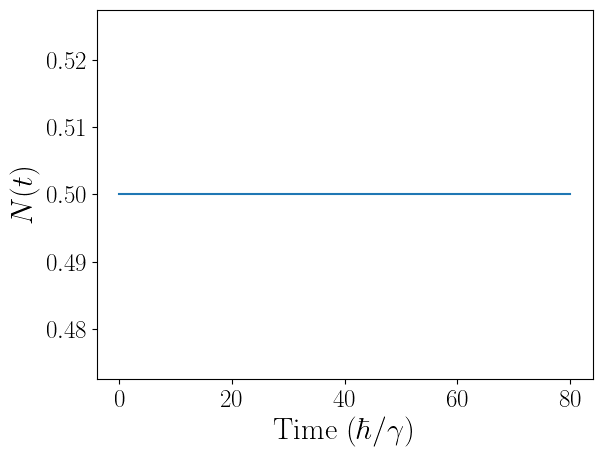

PyObject Text(40.38853188347517, 0.5, '$N(t)$')

In [21]:
n = [sum(imag.(GL_data[t1,t1]))/L for ti in 1:length(ts)]
plt.plot(ts,n)
xlabel(raw"$\mathrm{Time}\ (\hbar/\gamma)$")
ylabel(raw"$N(t)$")

### Windowing convention for two-time Fourier analysis
Define relative and average times
$$
\tau=t-t',\qquad t_\mathrm{avg}=\tfrac12(t+t').
$$
Because data exists on a finite square $(t,t')\in[0,t_\mathrm{max}]^2$, direct FFT in $\tau$ produces edge leakage. The Gaussian window
$$
W(\tau)=\exp\!\left[-2\tau^2/T^2\right]
$$
suppresses large-$|\tau|$ truncation artifacts while preserving central-$\tau$ information relevant for low/intermediate frequencies.

Limit to keep in mind: too narrow a window broadens frequency features; too broad a window reintroduces ringing.


In [22]:
Nt = length(ts)
T = maximum(ts)
Δ = ts .- ts'

# Gaussian window in relative time τ = t - t' to reduce FFT edge artifacts.
# This preserves central-time content while damping long-τ truncation noise.
W = @.exp(-2.0 * (Δ^2) / T^2)

GL_filt = similar(GL_data)
GG_filt = similar(GG_data)

for k in 1:size(GL_data,1)
    @views GL_filt[k, :, :] = GL_data[k, :, :] .* W
    @views GG_filt[k, :, :] = GG_data[k, :, :] .* W
end


In [23]:
"""
Compute Wigner transform on a (possibly) resampled uniform grid.
Input `x` is a two-time quantity x(t,t') for fixed momentum.
Returns transform over (ω, t_avg), with t_avg = (t+t')/2.
"""
function wigner_transform_itp(x, ts::Vector; fourier = true, ts_lin = range(first(ts), last(ts); length = length(ts)))
    itp = interpolate((ts, ts), x, Gridded(Linear()))
    return wigner_transform([itp(t1, t2) for t1 in ts_lin, t2 in ts_lin]; ts = ts_lin, fourier = fourier)
end


wigner_transform_itp (generic function with 1 method)

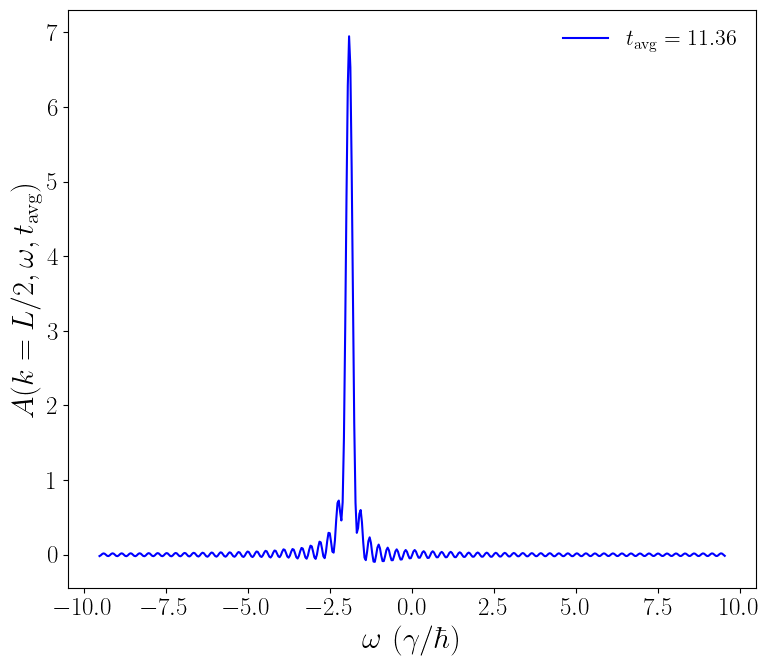

In [24]:
# Single-momentum diagnostic (k ≈ 0 when using Int(L/2) in this grid ordering).
GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[Int(L/2), :, :], ts; fourier=true)
GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt .- GL_filt)[Int(L/2), :, :], ts; fourier=true)

# Distribution-like ratio F and spectral function A from Keldysh components.
F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
A_Wigner = - imag(GR_Wigner_FFT)/pi

t_avg = 70
t_avg_sol = tavg[t_avg]

fig, ax = subplots(figsize=(8,7)) 
xlabel(raw"$\omega \,\, (\gamma/\hbar)$")
ylabel("\$ A(k=L/2,\\omega,t_{\\text{avg}})\$")
plot(ωs, A_Wigner[:, t_avg], label="\$t_{\\text{avg}} = $(round(t_avg_sol, digits=2))\$", color="blue", linewidth=1.5)
legend(frameon=false)
tight_layout()


In [25]:
GL_Wigner_list = []
F_Wigner_list = []
A_Wigner_list = []

tavg_list = []
ωs_list = []

# Momentum-resolved Wigner analysis for every k point.
for k in 1:L
    GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[k, :, :], ts; fourier=true)
    GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt - GL_filt)[k, :, :], ts; fourier=true)
    F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
    A_Wigner = - imag(GR_Wigner_FFT)/pi

    push!(GL_Wigner_list, GL_Wigner_FFT)
    push!(F_Wigner_list, F_Wigner)
    push!(A_Wigner_list, A_Wigner)
    
    push!(tavg_list, tavg)
    push!(ωs_list, ωs)
end


### Two-time to Wigner representation
The transform is performed at fixed momentum after interpolation to a uniform time grid:
$$
X(k,\omega,t_\mathrm{avg}) = \int d\tau\,e^{i\omega\tau}X\!\left(k,t_\mathrm{avg}+\tfrac{\tau}{2},t_\mathrm{avg}-\tfrac{\tau}{2}\right).
$$
Interpolation regularizes nonuniform solver timesteps before FFT. The resulting tensors are then reorganized as $(k,\omega,t_\mathrm{avg})$ for momentum-resolved or $k$-averaged analysis.


In [26]:
dim_tavg = size(GL_data)[2]

GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
F_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)

for i in 1:L
    for k in 1:dim_tavg
        for j in 1:dim_tavg
            GL_Wigner_tensor[i,j,k] = GL_Wigner_list[i][j,k]
            F_Wigner_tensor[i,j,k] = F_Wigner_list[i][j,k]
            A_Wigner_tensor[i,j,k] = A_Wigner_list[i][j,k]
        end
    end
end

In [27]:
# Brillouin-zone average: (1/L) Σ_k X(k, ω, t_avg).
@tullio GL_Wigner_sumk[i_ωs,i_tavg] := GL_Wigner_tensor[k,i_ωs,i_tavg];
@tullio A_Wigner_sumk[i_ωs,i_tavg] := A_Wigner_tensor[k,i_ωs,i_tavg];

GL_Wigner_sumk = GL_Wigner_sumk./L
A_Wigner_sumk = A_Wigner_sumk./L

# Effective distribution estimate from ratio Im G^< / A.
F_Wigner_sumk = (1/(2pi)) * imag.(GL_Wigner_sumk) ./ A_Wigner_sumk;


### Plotting and visualization
From Wigner-space components we use
$$
A(k,\omega,t_\mathrm{avg})=-\frac{1}{\pi}\,\mathrm{Im}\,G_k^R(\omega,t_\mathrm{avg}),
$$
$$
F(k,\omega,t_\mathrm{avg})\approx -\frac{1}{2}\frac{\mathrm{Im}\,G_k^<(\omega,t_\mathrm{avg})}{\mathrm{Im}\,G_k^R(\omega,t_\mathrm{avg})},
$$
with care near zeros of $\mathrm{Im}\,G^R$ (ratio instability).

When reading the heatmaps and cuts:
- shifts/broadening in $A$ diagnose drive + scattering renormalization,
- deviations of $F$ from Fermi shape indicate nonequilibrium population structure,
- $k$-averaged curves emphasize global redistribution, while $k$-resolved maps show momentum-selective transfer channels.


30.03037635125908


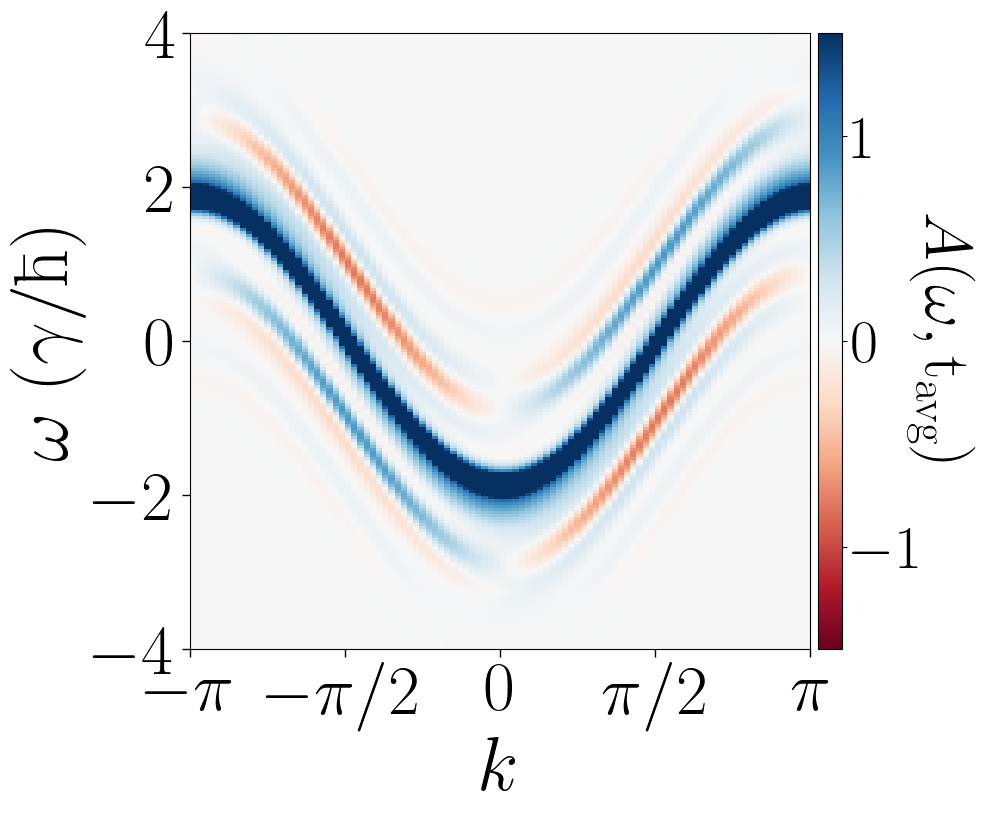

In [28]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

# t_avg1 = 210
# t_avg2 = 499
# t_avg3 = 504
# t_avg4 = 602

fs = 50
t_avg = 207
t_avg_sol = ts[t_avg]
println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.5, vmax=1.5)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
plt.ylim(-4,4)
box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$A\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)

55.80246913580247


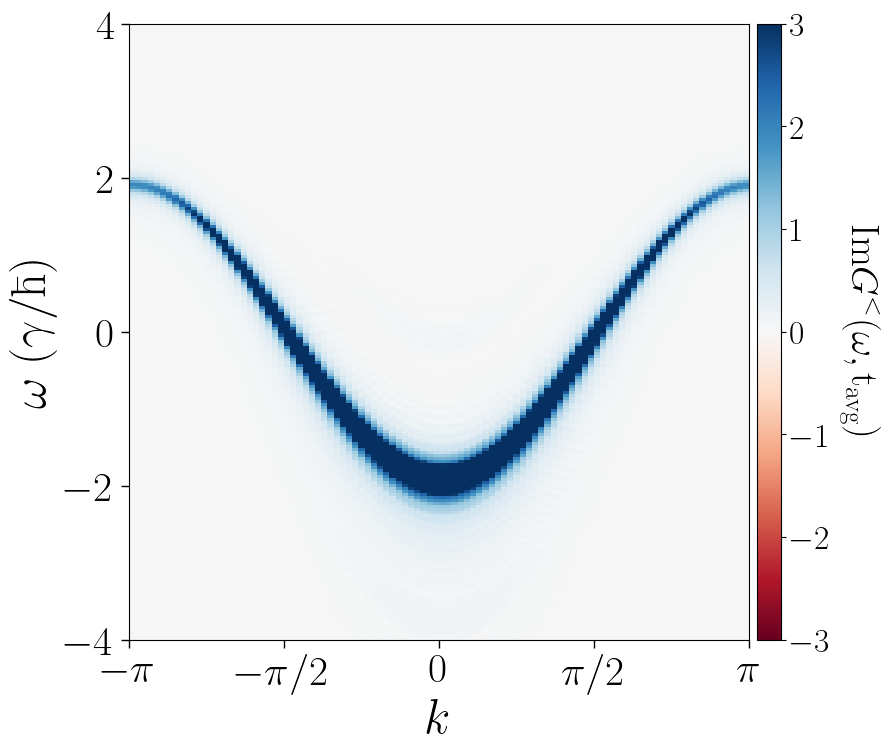

In [29]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

fs = 30
t_avg = 340
t_avg_sol = tavg[t_avg]

println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-3.0, vmax=3.0)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
plt.ylim(-4,4)
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)

box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)

55.1440329218107


sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


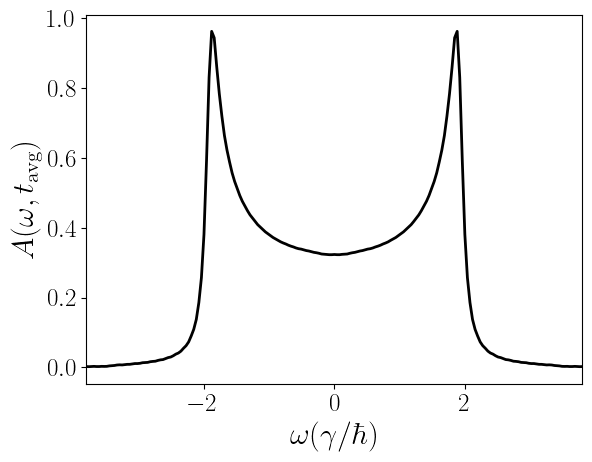

In [30]:
t_avg = 336#300
t_avg_sol = tavg[t_avg]

plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$A(\omega,t_{\text{avg}})$")
println(t_avg_sol)
plt.xlim(-3.8,3.8)
#plt.xlim(-8,8)
#plt.ylim(0,0.05)
plt.show()

In [31]:
# t_avg = 150#300
# t_avg_sol = tavg[t_avg]

# plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
# xlabel(raw"$\omega(\gamma/\hbar)$")
# ylabel(raw"$A(\omega,t_{\text{avg}})$")
# println(t_avg_sol)
# plt.xlim(-6,6)
# #plt.ylim(0,0.05)
# plt.show()

55.80246913580247


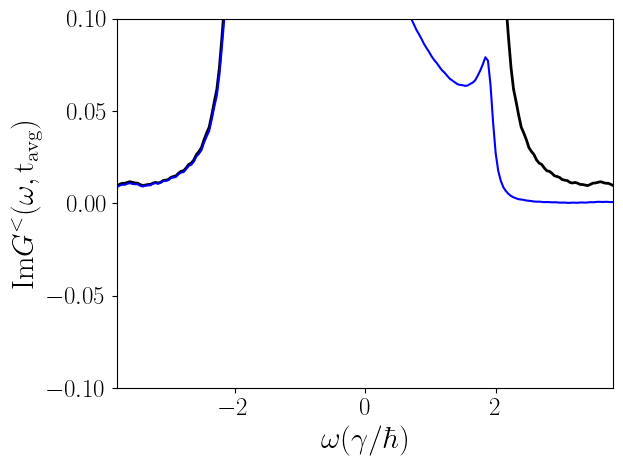

In [32]:
t_avg = 340
t_avg_sol = tavg[t_avg]
plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
plot(ωs, imag.(GL_Wigner_sumk[:,t_avg])/pi, color="blue", linewidth=1.5)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$")
#plt.xlim(-8,8)
plt.xlim(-3.8,3.8)
#plt.ylim(0,0.1)
println(t_avg_sol)
plt.ylim(-0.1,0.1)
plt.show()

In [67]:
model = ModelElectronBath()

ModelElectronBath{var"#93#98"{Float64, Float64, Float64, Float64, Float64, Float64, Vector{Float64}}}(100, 0.8, 0.0, 1.0, 0.2, 1.0, 3.0, 30.0, 2.2, 2.0, 0.5, 3.0, 20.0, 0.06283185307179587, [-3.141592653589793, -3.078760800517997, -3.015928947446201, -2.9530970943744057, -2.8902652413026098, -2.827433388230814, -2.764601535159018, -2.701769682087222, -2.6389378290154264, -2.5761059759436304  …  2.5132741228718345, 2.5761059759436304, 2.638937829015426, 2.701769682087222, 2.764601535159018, 2.827433388230814, 2.8902652413026098, 2.9530970943744053, 3.015928947446201, 3.078760800517997], var"#93#98"{Float64, Float64, Float64, Float64, Float64, Float64, Vector{Float64}}(0.0, 1.0, 30.0, 2.2, 2.0, 0.5, [-3.141592653589793, -3.078760800517997, -3.015928947446201, -2.9530970943744057, -2.8902652413026098, -2.827433388230814, -2.764601535159018, -2.701769682087222, -2.6389378290154264, -2.5761059759436304  …  2.5132741228718345, 2.5761059759436304, 2.638937829015426, 2.701769682087222, 2.76460

In [37]:
collect(tavg)

487-element Vector{Float64}:
  0.0
  0.1646090534979424
  0.3292181069958848
  0.49382716049382713
  0.6584362139917695
  0.823045267489712
  0.9876543209876543
  1.1522633744855968
  1.316872427983539
  1.4814814814814814
  1.646090534979424
  1.8106995884773662
  1.9753086419753085
  ⋮
 78.18930041152264
 78.35390946502058
 78.51851851851852
 78.68312757201646
 78.8477366255144
 79.01234567901234
 79.17695473251028
 79.34156378600824
 79.50617283950618
 79.67078189300412
 79.83539094650206
 80.0

In [38]:
tavg[180]

29.46502057613169

29.46502057613169


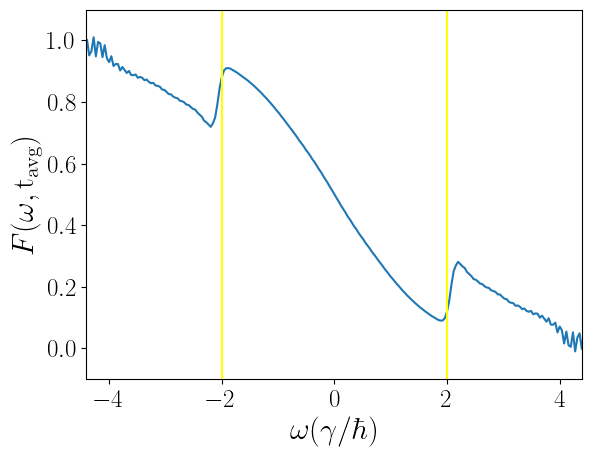

PyObject Text(41.51321041645046, 0.5, '$F\\mathrm{(\\omega,t_{\\text{avg}})}$')

In [35]:
# t_avg = 30
# t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
# δ = 1e-6
# A_col   = real.(A_Wigner_sumk[:, t_avg])
# GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# # Máscara de puntos "seguros"
# mask = abs.(A_col) .> δ
# ratio1 = fill(NaN, length(A_col))
# ratio1[mask] .= GL_im[mask] ./ A_col[mask]

# plt.plot(ωs,ratio1)



#plt.plot(ωs,fermi.(ωs;model=model),ls="--")

t_avg = 180#185#340#185
t_avg_sol = tavg[t_avg]
println(t_avg_sol)
δ = 1e-6
A_col   = real.(A_Wigner_sumk[:, t_avg])
GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# Máscara de puntos "seguros"
mask = abs.(A_col) .> δ
ratio = fill(NaN, length(A_col))
ratio[mask] .= GL_im[mask] ./ A_col[mask]

plt.plot(ωs,ratio)

# plt.xlim(-6,6)
plt.ylim(-0.1,1.1)
plt.axvline(2,color="yellow")
plt.axvline(-2,color="yellow")


plt.xlim(-4.4,4.4)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$F\mathrm{(\omega,t_{\text{avg}})}$")

In [74]:
fermi.(ωs;model=model)
model.T

10.0